In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation



In [ ]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [ ]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

In [ ]:
blinkDistance = distance.BlinkDistance()
blinkColors = Colors()
blinkCorrelations = Correlation()

df_webgazer["isBlinkColors"] = df_webgazer.apply(
    lambda row: blinkColors.isBlinkByColors(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


# df_webgazer['isBlinkByDistance'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByDistance(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

In [ ]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[7]==True))
df_webgazer["Blink_sample8"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample9"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[9]==True))
df_webgazer["Blink_sample10"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample11"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[12]==True))
df_webgazer["Blink_sample12"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[13]==True))
df_webgazer["Blink_sample13"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[13]==True))
df_webgazer["Blink_sample14"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[14]==True))

In [ ]:
df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])
df_webgazer["Blink_sample6_diff"] = (df_webgazer['Blink_sample6'].shift(1)+1 == df_webgazer['Blink_sample6'])
df_webgazer["Blink_sample7_diff"] = (df_webgazer['Blink_sample7'].shift(1)+1 == df_webgazer['Blink_sample7'])
df_webgazer["Blink_sample8_diff"] = (df_webgazer['Blink_sample8'].shift(1)+1 == df_webgazer['Blink_sample8'])
df_webgazer["Blink_sample9_diff"] = (df_webgazer['Blink_sample9'].shift(1)+1 == df_webgazer['Blink_sample9'])
df_webgazer["Blink_sample10_diff"] = (df_webgazer['Blink_sample10'].shift(1)+1 == df_webgazer['Blink_sample10'])
df_webgazer["Blink_sample11_diff"] = (df_webgazer['Blink_sample11'].shift(1)+1 == df_webgazer['Blink_sample11'])
df_webgazer["Blink_sample12_diff"] = (df_webgazer['Blink_sample12'].shift(1)+1 == df_webgazer['Blink_sample12'])
df_webgazer["Blink_sample13_diff"] = (df_webgazer['Blink_sample13'].shift(1)+1 == df_webgazer['Blink_sample13'])
df_webgazer["Blink_sample14_diff"] = (df_webgazer['Blink_sample14'].shift(1)+1 == df_webgazer['Blink_sample14'])

results = []
for x in range(0,15):
    tmp_result = df_webgazer.groupby(['trial', 'file_name'])['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

cleaned_results = [results[0]] + [df.drop(columns=['trial', 'file_name']) for df in results[1:]]
result = pd.concat(cleaned_results, axis=1)
result

In [ ]:
threshold_columns = [col for col in result.columns if col not in ['trial', 'file_name']]
result['should_be'] = result['trial'].apply(lambda x: 2 if x == 3 else 10)
result[result['trial']==3]

In [ ]:
threshold_columns = result.columns[2:-1]
threshold_columns

In [19]:
metodo = "COLORS"

# Obtener las columnas de thresholds (excluyendo 'trial' y 'Should be')
threshold_columns = result.columns[2:-1]

threshold_values = ["0,78-0,85", "0,8-0,9",	"0,7-0,8", "0,6-0,8", "0,7-0,9", "0,65-0,85", "0,71-0,81", "0,71-0,79", "0,73-0,77", "0,68-0,82"]
results_global = []
for i, threshold in enumerate(threshold_columns):
    preds = result[threshold]
    truth = result['should_be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results_global.append({'Threshold': threshold_values[i], 'Error Absoluto Medio': mae, 'Error Cuadrático Medio': rmse})

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Cuadrático Medio')

results_global_df.head()

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Absoluto Medio')

results_global_df.head()


,Threshold,Error Absoluto Medio,Error Cuadrático Medio
10,0.31,2.684211,5.973626
9,0.30,2.828947,6.321434
8,0.29,2.881579,6.428759
4,0.25,4.684211,6.797832
11,0.33,3.118421,6.871949


<Figure size 1400x700 with 0 Axes>

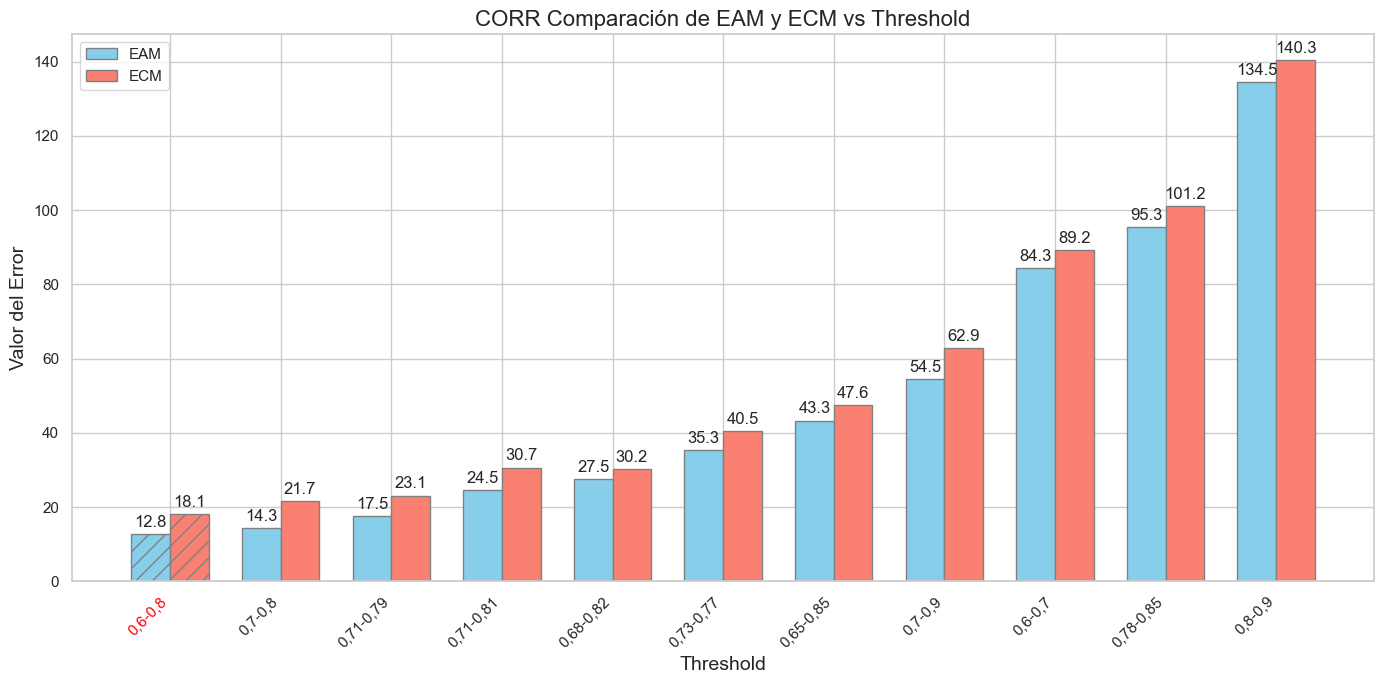


Resultados detallados:
Threshold       EAM       ECM
  0,6-0,8 12.833333 18.106168
  0,7-0,8 14.333333 21.656408
0,71-0,79 17.500000 23.126464
0,71-0,81 24.500000 30.656701
0,68-0,82 27.500000 30.229676


In [19]:
# Configuración de estilo
sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))

# Eliminar la fila 'total'
data = data[data['trial'] != 'total']

# Columnas de thresholds (excluyendo 'trial' y 'Should be')
thresholds = data.columns[1:-1]

# Calcular MAE y RMSE para cada threshold
metrics = []
for col in thresholds:
    errors = data[col] - data['Should be']
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    metrics.append({'Threshold': col, 'EAM': mae, 'ECM': rmse})

# Crear DataFrame con los resultados
metrics_df = pd.DataFrame(metrics).sort_values(by='EAM')

# Gráfico combinado (MAE y RMSE)
plt.figure(figsize=(14, 7))
bar_width = 0.35
x = np.arange(len(metrics_df))

# Barras para MAE
bars_mae = plt.bar(x - bar_width/2, metrics_df['EAM'], width=bar_width, 
                   color='skyblue', label='EAM', edgecolor='grey')

# Barras para RMSE
bars_rmse = plt.bar(x + bar_width/2, metrics_df['ECM'], width=bar_width, 
                    color='salmon', label='ECM', edgecolor='grey')

# Añadir etiquetas y formato
plt.title(metodo + ' Comparación de EAM y ECM vs Threshold', fontsize=16)
plt.xlabel('Threshold', fontsize=14)
plt.ylabel('Valor del Error', fontsize=14)
plt.xticks(x, metrics_df['Threshold'], rotation=45, ha='right')
plt.legend()

# Etiquetas con valores
for bar in bars_mae + bars_rmse:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}',
                 (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom',
                 xytext=(0, 3),
                 textcoords='offset points')

# Resaltar el mejor threshold (MAE más bajo)
best_idx = metrics_df['EAM'].idxmin()
plt.gca().get_xticklabels()[0].set_color('red')
bars_mae[0].set_hatch('//')  # Patrón para resaltar
bars_rmse[0].set_hatch('//')  # Patrón para resaltar


plt.tight_layout()
plt.show()

# Mostrar tabla de resultados
print("\nResultados detallados:")
print(metrics_df.head().to_string(index=False))

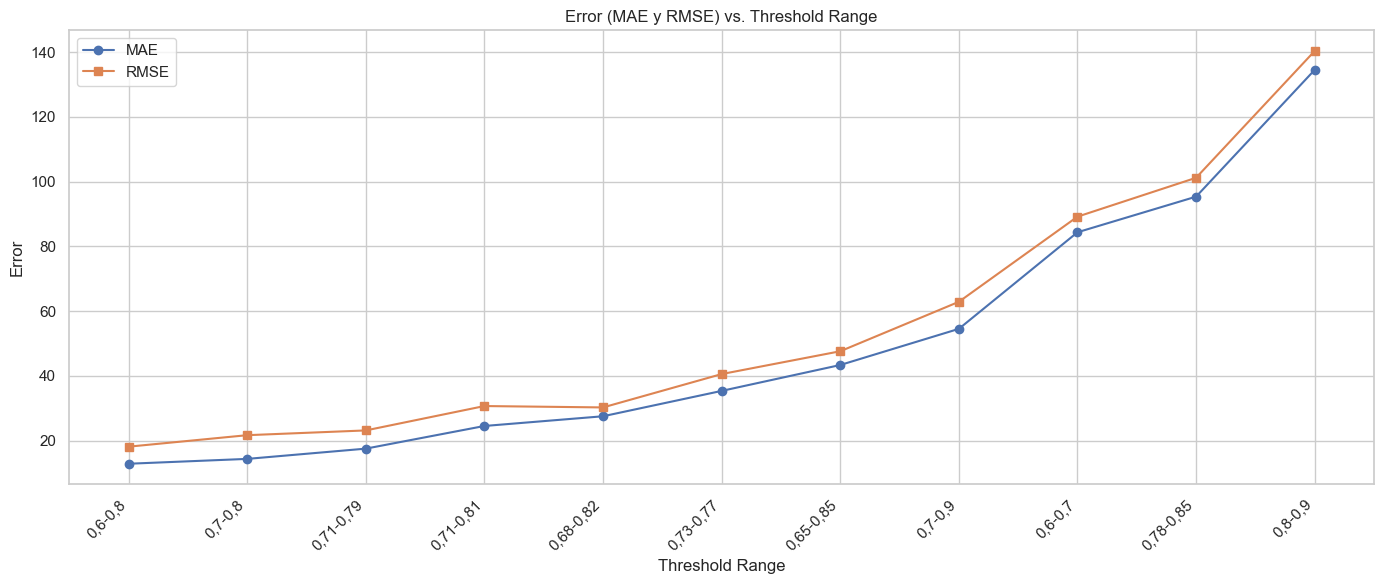

In [20]:

# Filtrar columnas que contienen valores de thresholds
threshold_columns = [col for col in data.columns if col not in ['trial', 'Should be']]

# Calcular MAE y RMSE
results = []
for col in threshold_columns:
    preds = data[col]
    truth = data['Should be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results.append({'Threshold Range': col, 'MAE': mae, 'RMSE': rmse})

# Convertir a DataFrame y ordenar
results_df = pd.DataFrame(results).sort_values(by='MAE')

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(results_df['Threshold Range'], results_df['MAE'], marker='o', label='MAE')
plt.plot(results_df['Threshold Range'], results_df['RMSE'], marker='s', label='RMSE')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Threshold Range')
plt.ylabel('Error')
plt.title('Error (MAE y RMSE) vs. Threshold Range')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
metrics_df.head()

,Threshold,EAM,ECM
6,"0,6-0,7",12.333333,16.237816
7,"0,61-0,71",12.500000,15.900734
8,"0,61-0,69",17.666667,22.181073
10,"0,58-0,72",19.500000,23.745175
5,"0,55-0,75",30.666667,35.711809
